# Skills Taxonomy Drift Analysis

This notebook performs a comprehensive drift analysis to understand how out of date our skills taxonomy is compared to the latest Lightcast versions.

## Objective
- Compare skills currently in use against the comprehensive Lightcast skills library
- Identify skills that are outdated based on their `latest_version` field
- Provide insights into the scale and distribution of taxonomy drift

## Data Sources
1. **Comprehensive Skills Library**: `data/skills_library/lightcast_skills_comprehensive.csv`
   - Contains all Lightcast skills with `latest_version` field indicating when skill last appeared
2. **Skills in Use**: `data/input_data/job_skill_mapping.csv`
   - Contains job-skill mappings showing which skills are actively used


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up plotting parameters
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully")

Libraries imported successfully


## 1. Data Loading and Initial Exploration


In [2]:
# Load the comprehensive skills library
print("Loading comprehensive skills library...")
skills_comprehensive = pd.read_csv('../data/skills_library/lightcast_skills_comprehensive.csv')

print(f"Comprehensive skills library loaded: {len(skills_comprehensive):,} records")
print(f"Columns: {list(skills_comprehensive.columns)}")
print("\nFirst few records:")
skills_comprehensive.head()


Loading comprehensive skills library...
Comprehensive skills library loaded: 38,395 records
Columns: ['skill_id', 'name', 'description', 'description_source', 'info_url', 'is_language', 'category_id', 'category_name', 'subcategory_id', 'subcategory_name', 'type_id', 'type_name', 'tag_names', 'tag_ids', 'latest_version', 'category', 'subcategory', 'tags', 'type', 'processed_at']

First few records:


,skill_id,name,description,description_source,info_url,is_language,category_id,category_name,subcategory_id,subcategory_name,type_id,type_name,tag_names,tag_ids,latest_version,category,subcategory,tags,type,processed_at
0,BGS1024316C916ACCFA3,DX Spectrum,NaN,NaN,https://lightcast.io/open-skills/skills/BGS102...,False,17.0,Information Technology,411.0,Enterprise Information Management,ST1,Specialized Skill,NaN,NaN,8.50,NaN,NaN,NaN,NaN,NaN
1,BGS105C99F084505B956,Microsoft Sysprep,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.31,NaN,NaN,NaN,Specialized Skill,2025-06-10T20:21:29.226230
2,BGS1080D1F8CED414379,Application Remediation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.31,NaN,NaN,NaN,Specialized Skill,2025-06-10T20:21:29.083601
3,BGS10AB6DEBB81A2E88C,Clinical Assay,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.31,NaN,NaN,NaN,Specialized Skill,2025-06-10T20:21:29.209095
4,BGS10B5E145CA48862FC,Welding Tips,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.31,NaN,NaN,NaN,Specialized Skill,2025-06-10T20:21:29.241181


In [3]:
# Load the job-skill mapping (skills in use)
print("Loading job-skill mapping...")
job_skill_mapping = pd.read_csv('../data/input_data/job_skill_mapping.csv')

print(f"Job-skill mapping loaded: {len(job_skill_mapping):,} records")
print(f"Columns: {list(job_skill_mapping.columns)}")
print(f"Unique skills in use: {job_skill_mapping['Skill_ID'].nunique():,}")
print(f"Unique job profiles: {job_skill_mapping['JobProfileID'].nunique():,}")
print("\nFirst few records:")
job_skill_mapping.head()

Loading job-skill mapping...
Job-skill mapping loaded: 40,170 records
Columns: ['JobProfileID', 'Skill_ID']
Unique skills in use: 2,091
Unique job profiles: 715

First few records:


,JobProfileID,Skill_ID
0,R0001.5,BGSD16A8EEF4F5775E15
1,R0001.5,ES147CB8BEA5CF1AF1F6
2,R0001.5,ES203B9B0426DA590EDF
3,R0001.5,ES20CECA4FF83ECE8196
4,R0001.5,ES42E5D7967FCC7EDD0D


In [4]:
# Examine the latest_version field distribution
print("Examining latest_version field:")
print(f"Non-null latest_version values: {skills_comprehensive['latest_version'].notna().sum():,}")
print(f"Null latest_version values: {skills_comprehensive['latest_version'].isna().sum():,}")
print(f"Unique latest_version values: {skills_comprehensive['latest_version'].nunique()}")

# Show distribution of latest_version values
print("\nDistribution of latest_version values:")
version_counts = skills_comprehensive['latest_version'].value_counts().sort_index()
print(version_counts.head(10))  # Show top 10 to avoid overwhelming output


Examining latest_version field:
Non-null latest_version values: 38,395
Null latest_version values: 0
Unique latest_version values: 48

Distribution of latest_version values:
latest_version
8.00      10
8.10      49
8.11      41
8.12      12
8.13      15
8.14    2025
8.15       4
8.16     857
8.17       3
8.18      14
Name: count, dtype: int64


## 2. Data Preparation and Cleaning


In [5]:
# Get unique skills currently in use
skills_in_use = set(job_skill_mapping['Skill_ID'].unique())
print(f"Unique skills currently in use: {len(skills_in_use):,}")

# Filter comprehensive skills to only those with latest_version data
skills_with_version = skills_comprehensive.dropna(subset=['latest_version']).copy()
print(f"Skills with version information: {len(skills_with_version):,}")

# Convert latest_version to numeric for analysis
skills_with_version['latest_version_numeric'] = pd.to_numeric(skills_with_version['latest_version'], errors='coerce')
print(f"Skills with valid numeric version: {skills_with_version['latest_version_numeric'].notna().sum():,}")


Unique skills currently in use: 2,091
Skills with version information: 38,395
Skills with valid numeric version: 38,395


In [6]:
# Create a flag for skills currently in use
skills_with_version['is_in_use'] = skills_with_version['skill_id'].isin(skills_in_use)

print(f"Skills in comprehensive library that are currently in use: {skills_with_version['is_in_use'].sum():,}")
print(f"Skills in use but not found in comprehensive library: {len(skills_in_use - set(skills_with_version['skill_id'])):,}")

# Show sample of skills in use but not in comprehensive library
missing_skills = skills_in_use - set(skills_with_version['skill_id'])
if missing_skills:
    print(f"\nSample of skills in use but not in comprehensive library:")
    print(list(missing_skills)[:10])


Skills in comprehensive library that are currently in use: 2,059
Skills in use but not found in comprehensive library: 32

Sample of skills in use but not in comprehensive library:
['BGS91833D85A87367BA1"', 'KS4403G6XNX5KJSD906W"', 'KS1218D6lys1Z647NCW2', 'Conflict Management', 'KS1254R6D2Y03RHKCVHR"', 'BGSA09D67D5649D8559E"', 'KS121T569X502KJPS0F3"', 'KS122LP5Z969YKTZ5R6C"', 'KS441S06L3NZBK0D6JM8"', 'S982FDA4CA23E7A3D3F']


## 3. Drift Analysis - Version Distribution


In [7]:
# Analyse version distribution for skills in use vs all skills
skills_in_use_analysis = skills_with_version[skills_with_version['is_in_use']].copy()

print("=== VERSION DISTRIBUTION ANALYSIS ===")
print(f"\nSkills currently in use with version data: {len(skills_in_use_analysis):,}")

# Calculate statistics for skills in use
version_stats_in_use = skills_in_use_analysis['latest_version_numeric'].describe()
print("\nVersion statistics for skills currently in use:")
print(version_stats_in_use)

# Compare with overall version statistics
version_stats_all = skills_with_version['latest_version_numeric'].describe()
print("\nVersion statistics for all skills in comprehensive library:")
print(version_stats_all)


=== VERSION DISTRIBUTION ANALYSIS ===

Skills currently in use with version data: 2,059

Version statistics for skills currently in use:
count    2059.00
mean        9.31
std         0.00
min         9.31
25%         9.31
50%         9.31
75%         9.31
max         9.31
Name: latest_version_numeric, dtype: float64

Version statistics for all skills in comprehensive library:
count    38395.000000
mean         9.203733
std          0.329043
min          8.000000
25%          9.310000
50%          9.310000
75%          9.310000
max          9.310000
Name: latest_version_numeric, dtype: float64


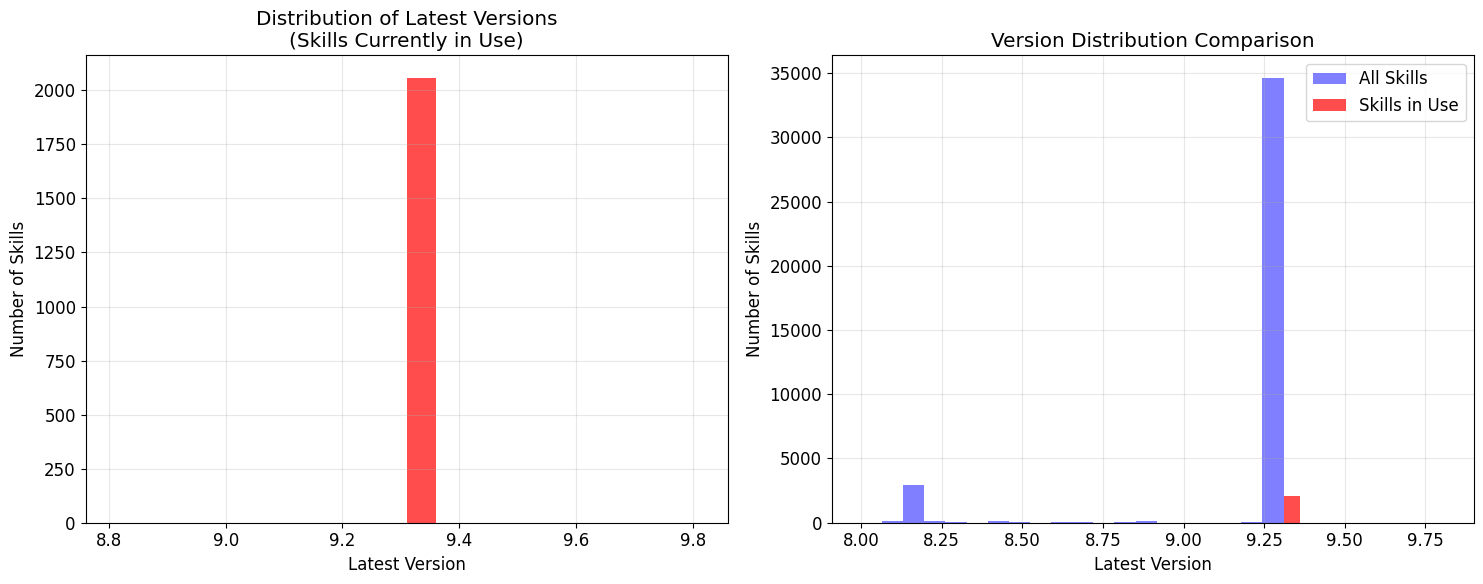

In [8]:
# Create visualisation of version distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of versions for skills in use
ax1.hist(skills_in_use_analysis['latest_version_numeric'].dropna(), bins=20, alpha=0.7, color='red', label='Skills in Use')
ax1.set_xlabel('Latest Version')
ax1.set_ylabel('Number of Skills')
ax1.set_title('Distribution of Latest Versions\n(Skills Currently in Use)')
ax1.grid(True, alpha=0.3)

# Comparison histogram
ax2.hist(skills_with_version['latest_version_numeric'].dropna(), bins=20, alpha=0.5, color='blue', label='All Skills')
ax2.hist(skills_in_use_analysis['latest_version_numeric'].dropna(), bins=20, alpha=0.7, color='red', label='Skills in Use')
ax2.set_xlabel('Latest Version')
ax2.set_ylabel('Number of Skills')
ax2.set_title('Version Distribution Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Detailed Drift Analysis


In [9]:
# Define version thresholds for drift analysis
# Assuming higher version numbers = more recent
current_max_version = skills_with_version['latest_version_numeric'].max()
print(f"Current maximum version in dataset: {current_max_version}")

# Define drift categories based on version gaps
def categorise_drift(version, max_version):
    if pd.isna(version):
        return 'Unknown'
    
    version_gap = max_version - version
    
    if version_gap <= 0.5:
        return 'Current (≤0.5 versions behind)'
    elif version_gap <= 1.0:
        return 'Slightly Outdated (0.5-1.0 versions behind)'
    elif version_gap <= 2.0:
        return 'Moderately Outdated (1.0-2.0 versions behind)'
    elif version_gap <= 3.0:
        return 'Significantly Outdated (2.0-3.0 versions behind)'
    else:
        return 'Severely Outdated (>3.0 versions behind)'

# Apply drift categorisation
skills_in_use_analysis['drift_category'] = skills_in_use_analysis['latest_version_numeric'].apply(
    lambda x: categorise_drift(x, current_max_version)
)

# Calculate drift distribution
drift_distribution = skills_in_use_analysis['drift_category'].value_counts()
print("\n=== DRIFT ANALYSIS RESULTS ===")
print("Distribution of skills by drift category:")
for category, count in drift_distribution.items():
    percentage = (count / len(skills_in_use_analysis)) * 100
    print(f"{category}: {count:,} skills ({percentage:.1f}%)")


Current maximum version in dataset: 9.31

=== DRIFT ANALYSIS RESULTS ===
Distribution of skills by drift category:
Current (≤0.5 versions behind): 2,059 skills (100.0%)


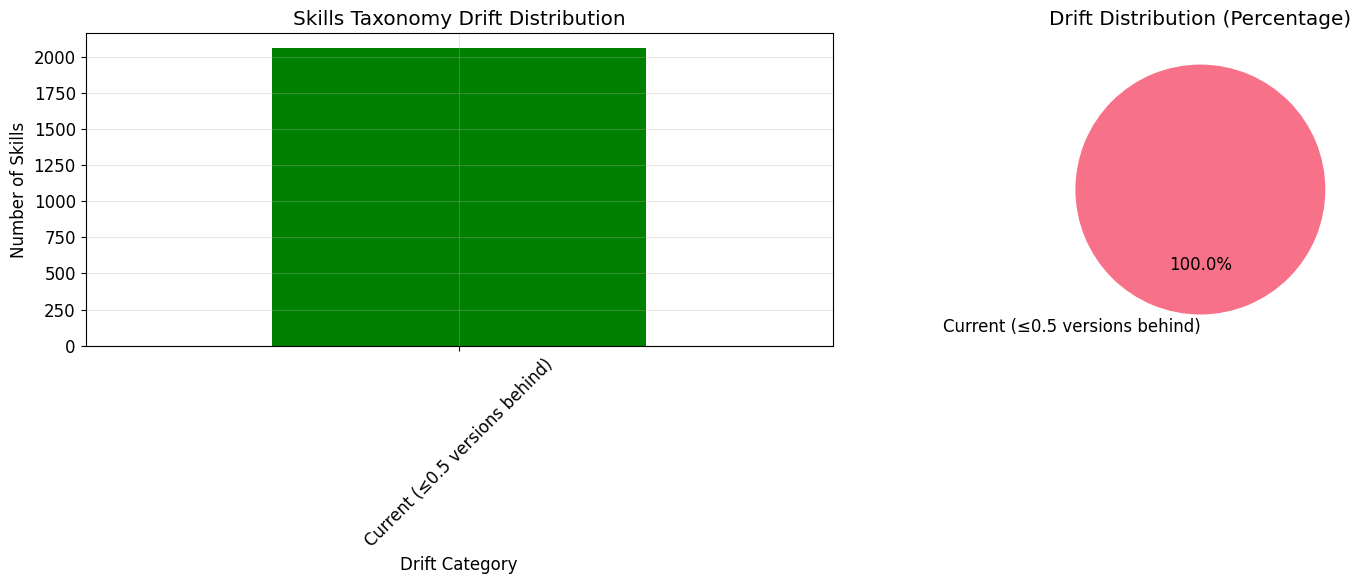

In [10]:
# Visualise drift distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
drift_distribution.plot(kind='bar', ax=ax1, color=['green', 'yellow', 'orange', 'red', 'darkred'])
ax1.set_title('Skills Taxonomy Drift Distribution')
ax1.set_xlabel('Drift Category')
ax1.set_ylabel('Number of Skills')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Pie chart
ax2.pie(drift_distribution.values, labels=drift_distribution.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Drift Distribution (Percentage)')

plt.tight_layout()
plt.show()


## 5. Category-Based Drift Analysis


In [11]:
# Analyse drift by skill category
print("=== DRIFT ANALYSIS BY SKILL CATEGORY ===")

# Check available category columns
category_columns = [col for col in skills_in_use_analysis.columns if 'category' in col.lower()]
print(f"Available category columns: {category_columns}")

# Use the most appropriate category column
if 'category_name' in skills_in_use_analysis.columns:
    category_col = 'category_name'
elif 'category' in skills_in_use_analysis.columns:
    category_col = 'category'
else:
    category_col = None

if category_col and skills_in_use_analysis[category_col].notna().sum() > 0:
    # Create cross-tabulation of categories vs drift
    category_drift = pd.crosstab(skills_in_use_analysis[category_col].fillna('Unknown'), 
                                skills_in_use_analysis['drift_category'])
    
    print(f"\nDrift analysis by {category_col}:")
    print(category_drift)
    
    # Calculate percentages
    category_drift_pct = category_drift.div(category_drift.sum(axis=1), axis=0) * 100
    print(f"\nDrift percentages by {category_col}:")
    print(category_drift_pct.round(1))
else:
    print("No suitable category column found for detailed analysis")
    category_col = None


=== DRIFT ANALYSIS BY SKILL CATEGORY ===
Available category columns: ['category_id', 'category_name', 'subcategory_id', 'subcategory_name', 'category', 'subcategory', 'drift_category']
No suitable category column found for detailed analysis


In [12]:
# Visualise category-based drift if data is available
if category_col and 'category_drift_pct' in locals():
    fig, ax = plt.subplots(figsize=(14, 8))
    category_drift_pct.plot(kind='bar', stacked=True, ax=ax, 
                           color=['green', 'yellow', 'orange', 'red', 'darkred'])
    ax.set_title(f'Skills Drift Distribution by {category_col.replace("_", " ").title()}')
    ax.set_xlabel(category_col.replace('_', ' ').title())
    ax.set_ylabel('Percentage of Skills')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Drift Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Category-based visualisation not available - insufficient data")


Category-based visualisation not available - insufficient data


## 6. Most Outdated Skills Analysis


In [13]:
# Identify the most outdated skills currently in use
print("=== MOST OUTDATED SKILLS ANALYSIS ===")

# Calculate version gap for each skill
skills_in_use_analysis['version_gap'] = current_max_version - skills_in_use_analysis['latest_version_numeric']

# Get the most outdated skills
display_columns = ['skill_id', 'name', 'latest_version_numeric', 'version_gap', 'drift_category']
if 'category_name' in skills_in_use_analysis.columns:
    display_columns.append('category_name')

most_outdated = skills_in_use_analysis.nlargest(20, 'version_gap')[display_columns]

print("Top 20 most outdated skills currently in use:")
print(most_outdated.to_string(index=False))

# Count skills by severity
severely_outdated = skills_in_use_analysis[skills_in_use_analysis['drift_category'] == 'Severely Outdated (>3.0 versions behind)']
print(f"\nNumber of severely outdated skills (>3.0 versions behind): {len(severely_outdated):,}")

if len(severely_outdated) > 0:
    print(f"Average version gap for severely outdated skills: {severely_outdated['version_gap'].mean():.2f}")
    print(f"Maximum version gap: {severely_outdated['version_gap'].max():.2f}")


=== MOST OUTDATED SKILLS ANALYSIS ===
Top 20 most outdated skills currently in use:
            skill_id                            name  latest_version_numeric  version_gap                 drift_category category_name
BGS10EE289B9FDE2C4B1   Investment Account Management                    9.31          0.0 Current (≤0.5 versions behind)           NaN
BGS11665AC6BD06C5EBD               Payroll Reporting                    9.31          0.0 Current (≤0.5 versions behind)           NaN
BGS117E3FE9519A5B542        Joint Venture Accounting                    9.31          0.0 Current (≤0.5 versions behind)           NaN
BGS1241B6719A7FE041D     Cloud Security Applications                    9.31          0.0 Current (≤0.5 versions behind)           NaN
BGS1250D82C4B027A171             Accounting Analysis                    9.31          0.0 Current (≤0.5 versions behind)           NaN
BGS147DBB4CF132F0523      Service Quality Management                    9.31          0.0 Current (≤0.5 ve

## 7. Usage Frequency vs Drift Analysis


In [14]:
# Analyse how frequently outdated skills are used
print("=== USAGE FREQUENCY vs DRIFT ANALYSIS ===")

# Count usage frequency for each skill
skill_usage_counts = job_skill_mapping['Skill_ID'].value_counts()
skills_in_use_analysis['usage_frequency'] = skills_in_use_analysis['skill_id'].map(skill_usage_counts).fillna(0)

print(f"Usage frequency statistics:")
print(skills_in_use_analysis['usage_frequency'].describe())

# Analyse usage frequency by drift category
usage_by_drift = skills_in_use_analysis.groupby('drift_category')['usage_frequency'].agg([
    'count', 'mean', 'median', 'sum'
]).round(2)

print("\nUsage frequency by drift category:")
print(usage_by_drift)

# Calculate impact (total usage of outdated skills)
total_usage = skills_in_use_analysis['usage_frequency'].sum()
outdated_categories = ['Moderately Outdated (1.0-2.0 versions behind)', 
                      'Significantly Outdated (2.0-3.0 versions behind)',
                      'Severely Outdated (>3.0 versions behind)']

outdated_usage = skills_in_use_analysis[skills_in_use_analysis['drift_category'].isin(outdated_categories)]['usage_frequency'].sum()
outdated_impact = (outdated_usage / total_usage) * 100 if total_usage > 0 else 0

print(f"\n=== IMPACT ASSESSMENT ===")
print(f"Total skill usage instances: {total_usage:,}")
print(f"Usage instances with outdated skills: {outdated_usage:,}")
print(f"Percentage of usage impacted by outdated skills: {outdated_impact:.1f}%")


=== USAGE FREQUENCY vs DRIFT ANALYSIS ===
Usage frequency statistics:
count    2059.000000
mean       19.448762
std        66.544421
min         1.000000
25%         3.000000
50%         6.000000
75%        13.000000
max       666.000000
Name: usage_frequency, dtype: float64

Usage frequency by drift category:
                                count   mean  median    sum
drift_category                                             
Current (≤0.5 versions behind)   2059  19.45     6.0  40045

=== IMPACT ASSESSMENT ===
Total skill usage instances: 40,045
Usage instances with outdated skills: 0
Percentage of usage impacted by outdated skills: 0.0%


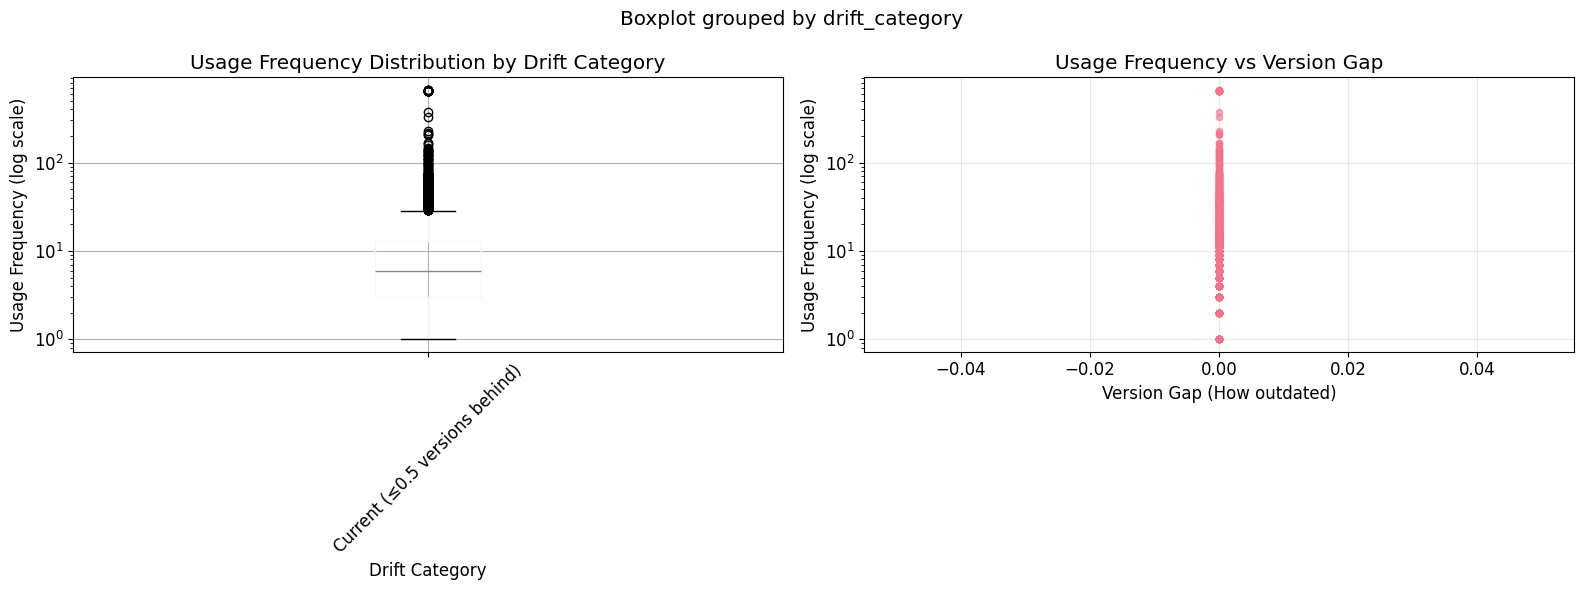

In [15]:
# Visualise usage vs drift relationship
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot of usage frequency by drift category
skills_in_use_analysis.boxplot(column='usage_frequency', by='drift_category', ax=ax1)
ax1.set_title('Usage Frequency Distribution by Drift Category')
ax1.set_xlabel('Drift Category')
ax1.set_ylabel('Usage Frequency (log scale)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', rotation=45)

# Scatter plot of version gap vs usage frequency
ax2.scatter(skills_in_use_analysis['version_gap'], 
           skills_in_use_analysis['usage_frequency'], 
           alpha=0.6, s=20)
ax2.set_xlabel('Version Gap (How outdated)')
ax2.set_ylabel('Usage Frequency (log scale)')
ax2.set_yscale('log')
ax2.set_title('Usage Frequency vs Version Gap')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Executive Summary and Recommendations


In [16]:
# Generate executive summary
print("=" * 60)
print("SKILLS TAXONOMY DRIFT ANALYSIS - EXECUTIVE SUMMARY")
print("=" * 60)

# Key metrics
total_skills_in_use = len(skills_in_use_analysis)
current_skills = len(skills_in_use_analysis[skills_in_use_analysis['drift_category'] == 'Current (≤0.5 versions behind)'])
outdated_skills = len(skills_in_use_analysis[skills_in_use_analysis['drift_category'].isin(outdated_categories)])
severely_outdated_count = len(skills_in_use_analysis[skills_in_use_analysis['drift_category'] == 'Severely Outdated (>3.0 versions behind)'])

print(f"\n📊 KEY METRICS:")
print(f"• Total skills currently in use: {total_skills_in_use:,}")
print(f"• Current/up-to-date skills: {current_skills:,} ({(current_skills/total_skills_in_use)*100:.1f}%)")
print(f"• Outdated skills (>1.0 versions behind): {outdated_skills:,} ({(outdated_skills/total_skills_in_use)*100:.1f}%)")
print(f"• Severely outdated skills (>3.0 versions behind): {severely_outdated_count:,} ({(severely_outdated_count/total_skills_in_use)*100:.1f}%)")

print(f"\n📈 USAGE IMPACT:")
print(f"• Total usage instances analysed: {total_usage:,}")
print(f"• Usage instances with outdated skills: {outdated_usage:,}")
print(f"• Percentage of usage impacted: {outdated_impact:.1f}%")

print(f"\n🎯 RECOMMENDATIONS:")
if outdated_impact > 30:
    priority = "HIGH"
    action = "Immediate action required"
elif outdated_impact > 15:
    priority = "MEDIUM"
    action = "Plan update within next quarter"
else:
    priority = "LOW"
    action = "Consider update in next review cycle"

print(f"• Priority Level: {priority}")
print(f"• Recommended Action: {action}")
print(f"• Focus on the {severely_outdated_count:,} severely outdated skills first")
print(f"• Review skills taxonomy update process to prevent future drift")

if category_col and 'category_drift_pct' in locals():
    worst_categories = category_drift_pct.mean(axis=1).nlargest(3)
    print(f"\n📍 CATEGORIES NEEDING ATTENTION:")
    for cat, avg_drift in worst_categories.items():
        print(f"• {cat}: {avg_drift:.1f}% average drift")

print("\n" + "="*60)


SKILLS TAXONOMY DRIFT ANALYSIS - EXECUTIVE SUMMARY

📊 KEY METRICS:
• Total skills currently in use: 2,059
• Current/up-to-date skills: 2,059 (100.0%)
• Outdated skills (>1.0 versions behind): 0 (0.0%)
• Severely outdated skills (>3.0 versions behind): 0 (0.0%)

📈 USAGE IMPACT:
• Total usage instances analysed: 40,045
• Usage instances with outdated skills: 0
• Percentage of usage impacted: 0.0%

🎯 RECOMMENDATIONS:
• Priority Level: LOW
• Recommended Action: Consider update in next review cycle
• Focus on the 0 severely outdated skills first
• Review skills taxonomy update process to prevent future drift



## 9. Export Results for Further Action


In [ ]:
# Export detailed results and create output directory if needed
import os
output_dir = '../data/output'
os.makedirs(output_dir, exist_ok=True)

# Export detailed results for action planning
export_columns = ['skill_id', 'name', 'latest_version_numeric', 'version_gap', 
                 'drift_category', 'usage_frequency']
if 'category_name' in skills_in_use_analysis.columns:
    export_columns.append('category_name')
if 'type_name' in skills_in_use_analysis.columns:
    export_columns.append('type_name')

export_data = skills_in_use_analysis[export_columns].sort_values('version_gap', ascending=False)

# Export to CSV
export_filename = f'{output_dir}/skills_drift_analysis_results.csv'
export_data.to_csv(export_filename, index=False)
print(f"Detailed results exported to: {export_filename}")

# Create summary statistics
summary_stats = {
    'total_skills_analysed': total_skills_in_use,
    'current_skills_count': current_skills,
    'current_skills_percentage': (current_skills/total_skills_in_use)*100,
    'outdated_skills_count': outdated_skills,
    'outdated_skills_percentage': (outdated_skills/total_skills_in_use)*100,
    'severely_outdated_count': severely_outdated_count,
    'severely_outdated_percentage': (severely_outdated_count/total_skills_in_use)*100,
    'usage_impact_percentage': outdated_impact,
    'priority_level': priority,
    'analysis_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'max_version_in_dataset': current_max_version,
    'skills_missing_from_library': len(missing_skills)
}

summary_df = pd.DataFrame([summary_stats])
summary_filename = f'{output_dir}/skills_drift_summary.csv'
summary_df.to_csv(summary_filename, index=False)
print(f"Summary statistics exported to: {summary_filename}")

print("\n✅ Analysis complete! Check the exported files for detailed results.")
